# Exploratory data analysis

## 1. Notebook setup

### 1.1. Imports

In [1]:
# Standard library
import json
from itertools import combinations

# Third-party
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway, kruskal, pearsonr

### 1.2. Data loading

In [2]:
df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/student-health-risk-train.csv')

## 2. Data inspection

### 2.1. Shape, format & summary statistics

In [3]:
df.head().T

,0,1,2,3,4
id,0,1,2,3,4
health_condition,unhealthy,at-risk,unhealthy,unhealthy,at-risk
sleep_duration,5.22,5.53,5.29,4.7,7.23
heart_rate,70.6,71.3,75.4,77.2,73.4
bmi,25.66,25.84,24.54,23.13,28.44
calorie_expenditure,2174.0,1966.0,2688.0,2630.0,2560.0
step_count,1326.0,9891.0,14216.0,7174.0,6584.0
exercise_duration,19.8,49.9,38.1,59.9,46.0
water_intake,1.86,1.26,1.6,2.02,2.25
diet_type,veg,non-veg,veg,veg,veg


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


The label is `health_condition`, comes in as object dtype, appears to contain string/categorical data. The 14 other columns are features. The `id` column can be dropped, leaving us 13 information containing features to work with. Six of the features appear to be categorical with object datatype and 7 are continuous. The feature `step_count` is discrete variable, with only integer counts possible. It could be considered a high cardinality categorical feature.

In [6]:
features = [
    'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
    'step_count', 'exercise_duration', 'water_intake', 'diet_type',
    'stress_level', 'sleep_quality', 'physical_activity_level',
    'smoking_alcohol', 'gender'
]

categorical_features = [
    'diet_type', 'stress_level', 'sleep_quality',
    'physical_activity_level', 'smoking_alcohol', 'gender'
]

continuous_features = [
    'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
    'step_count', 'exercise_duration', 'water_intake'
]

high_cardinality_feature = 'step_count'
label = 'health_condition'

metadata = {
    'features': features,
    'categorical_features': categorical_features,
    'continuous_features': continuous_features,
    'high_cardinality_feature' : high_cardinality_feature,
    'label': label
}

with open("../data/schema.json", "w") as f:
    json.dump(metadata, f)

### 2.2. Missing values

In [7]:
df.isna().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

All features have missing values, ranging from ~1.0% to ~1.2%.

In [8]:
# Get null counts by label
null_counts = df.drop('id', axis=1).isnull().groupby(df['health_condition']).sum()

# Drop the label null counts (which is zero
null_counts.drop('health_condition', axis=1, inplace=True)

display(null_counts.T)

health_condition,at-risk,fit,unhealthy
sleep_duration,65308,4356,6335
heart_rate,6821,433,579
bmi,12352,1139,407
calorie_expenditure,45350,3065,4438
step_count,11997,793,1126
exercise_duration,5872,417,612
water_intake,37177,2524,3776
diet_type,5987,351,563
stress_level,71130,4759,6922
sleep_quality,50143,3394,4794


In [9]:
results = {}

for col in features:

    # 1. Create a binary indicator for missingness (True if null, False if not)
    is_null = df[col].isnull()

    # 2. Build the 2 x 3 cross-tabulation table
    contingency_table = pd.crosstab(is_null, df[label])

    # 3. Run the Chi-squared test
    # stat: Chi-sq statistic, p: p-value, dof: degrees of freedom, expected: expected frequencies
    stat, p, dof, expected = chi2_contingency(contingency_table)

    # 4. Check assumption: are any expected cell counts less than 5?
    low_expected_counts = (expected < 5).any()

    results[col] = {
        'p_value': p,
        'chi2_stat': stat,
        'violates_assumption': low_expected_counts
    }

# Convert results to a readable DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

                          p_value   chi2_stat violates_assumption
sleep_duration           0.851123    0.322396               False
heart_rate               0.003861   11.113873               False
bmi                           0.0  660.986375               False
calorie_expenditure      0.907254    0.194666               False
step_count               0.453612    1.581028               False
exercise_duration        0.172269    3.517399               False
water_intake             0.038828    6.497219               False
diet_type                0.036695    6.610203               False
stress_level             0.958954    0.083824               False
sleep_quality            0.371979    1.977834               False
physical_activity_level  0.900317    0.210017               False
smoking_alcohol          0.495606     1.40395               False
gender                   0.217861    3.047798               False


The distribution of null values in several features appears to have a significant association with the label.

In [10]:
sig_features = results_df[results_df['p_value'] < 0.05].index
display(sig_features)

Index(['heart_rate', 'bmi', 'water_intake', 'diet_type'], dtype='object')

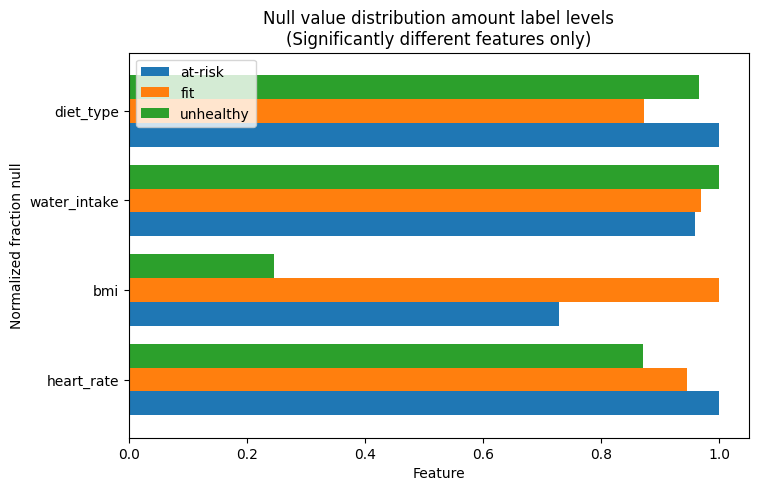

In [11]:
counts = df.drop('id', axis=1).groupby(df['health_condition']).count()
counts.drop('health_condition', axis=1, inplace=True)

normalized_fraction_null = (
    null_counts[sig_features] / (counts[sig_features] + null_counts[sig_features])
) / null_counts[sig_features].sum()

normalized_fraction_null = normalized_fraction_null / normalized_fraction_null.max()

ax = normalized_fraction_null.T.plot(kind='barh', figsize=(8, 5), width=0.8)
plt.title('Null value distribution amount label levels\n(Significantly different features only)')
plt.xlabel('Feature')
plt.ylabel('Normalized fraction null')
plt.legend(loc='upper left')
plt.show()

## 3. Distribution analysis

### 3.1. Label

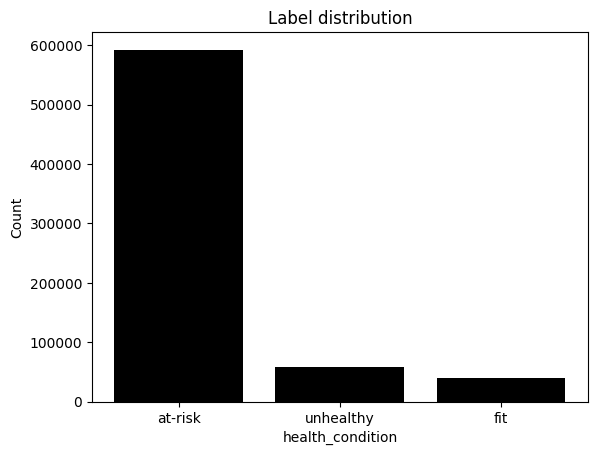

In [12]:
label_counts = df[label].value_counts()
plt.bar(label_counts.index, label_counts.values, color='black')
plt.title('Label distribution')
plt.xlabel(label)
plt.ylabel('Count')
plt.show()

### 3.2. Categorical features

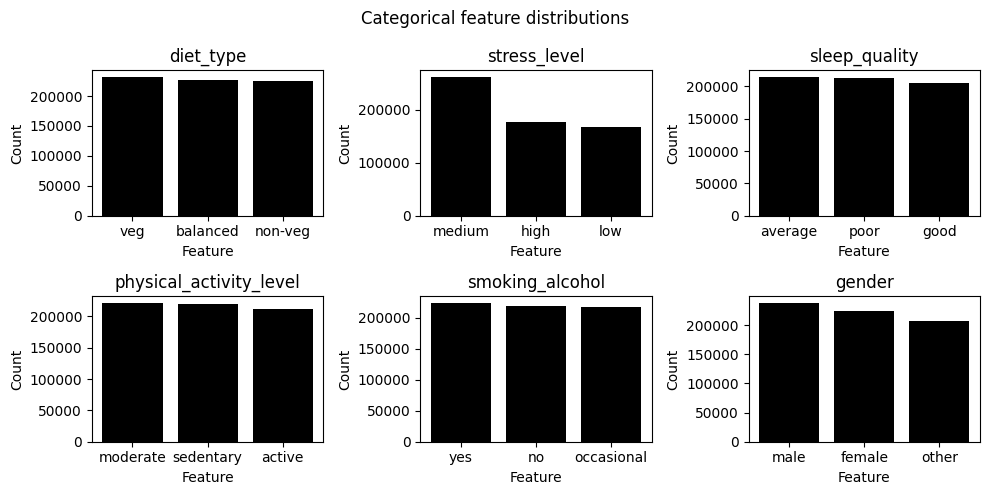

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs = axs.flatten()

fig.suptitle('Categorical feature distributions')

for i, feature in enumerate(categorical_features):

    feature_counts = df[feature].value_counts()
    axs[i].bar(feature_counts.index, feature_counts.values, color='black')
    axs[i].set_title(feature)
    axs[i].set_xlabel('Feature')
    axs[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3.3. Continuous features

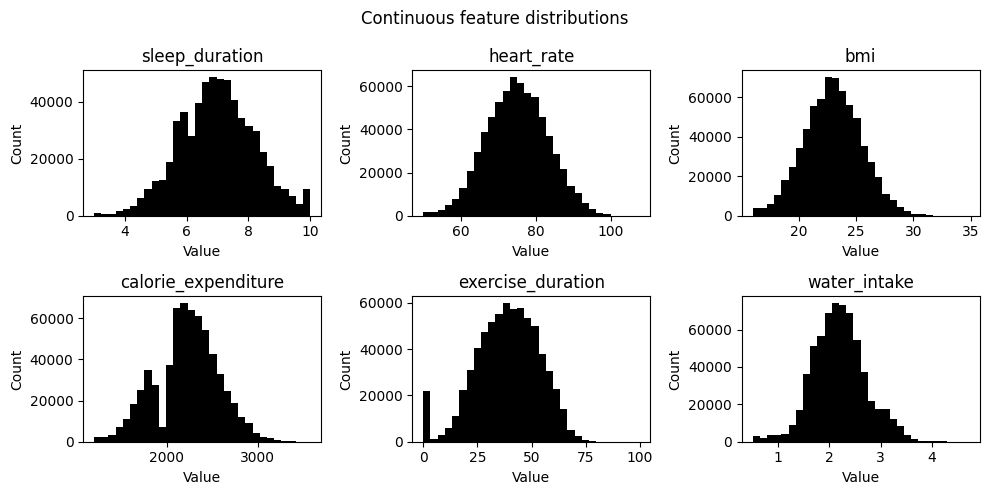

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs = axs.flatten()

fig.suptitle('Continuous feature distributions')

for i, feature in enumerate([f for f in continuous_features if f != 'step_count']):
    axs[i].hist(df[feature], bins=30, color='black')
    axs[i].set_title(feature)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3.4. High cardinality: `step_count`

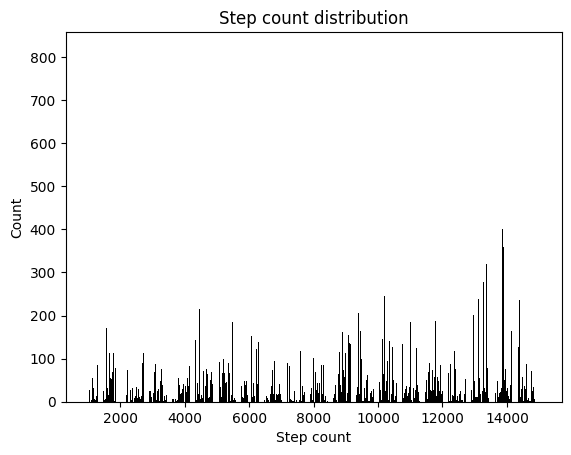

In [15]:
step_count_values = df['step_count'].value_counts()
plt.bar(step_count_values.index, step_count_values.values, color='black')
plt.title('Step count distribution')
plt.xlabel('Step count')
plt.ylabel('Count')
plt.show()

## 4. Interaction analysis

### 4.1. Feature-label

#### 4.1.1. Categorical features

##### Heatmaps

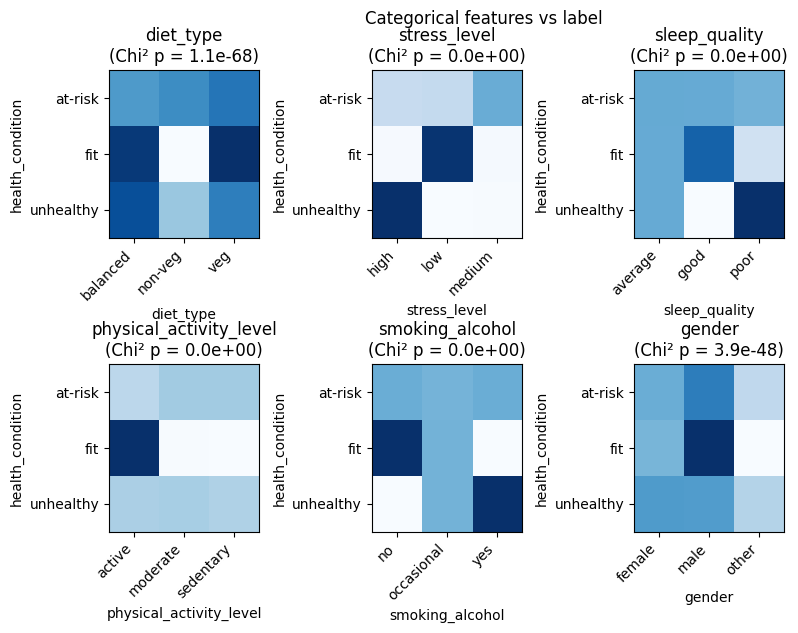

In [16]:
# Empty dictionary for results
chi2_results = {
    'Feature': [],
    'Chi² p-value': []
}

# Prepare figure and axes
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle('Categorical features vs label')
axs = axs.flatten()

# Loop over categorical features and create heatmaps
for i, feature in enumerate(categorical_features):

    # Create contingency table and run Chi² test
    contingency_df = pd.crosstab(df[label], df[feature])
    result = chi2_contingency(contingency_df)
    p_value = result[1]

    # Collect Chi² test results
    chi2_results['Feature'].append(feature)
    chi2_results['Chi² p-value'].append(p_value)

    # Normalize contingency table for heatmap visualization
    contingency_df = pd.crosstab(df[label], df[feature], normalize='index')

    # Plot heatmap for normalized contingency table
    axs[i].imshow(contingency_df, aspect='auto', cmap='Blues')
    axs[i].set_title(f'{feature}\n(Chi² p = {p_value:.1e})')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel(label)

    # Add feature level labels to x-axis
    axs[i].set_xticks(np.arange(len(contingency_df.columns)))
    axs[i].set_xticklabels(contingency_df.columns, rotation=45, ha='right')

    # Add feature level labels to y-axis
    axs[i].set_yticks(np.arange(len(contingency_df.index)))
    axs[i].set_yticklabels(contingency_df.index)

# Add one colorbar for the entire figure
#cbar = fig.colorbar(axs[0].images[0], ax=axs, orientation='vertical', fraction=.1)

# Add horizontal space between subplots
plt.subplots_adjust(hspace=0.75)

# Add vertical space between subplots
plt.subplots_adjust(wspace=0.75)

# Adjust layout to make room for colorbar
plt.subplots_adjust(right=0.8)
plt.show()

##### Chi² table

In [17]:
chi2_df = pd.DataFrame(chi2_results)
chi2_df.sort_values(by='Chi² p-value', inplace=True)
display(chi2_df)

,Feature,Chi² p-value
1,stress_level,0.000000e+00
2,sleep_quality,0.000000e+00
3,physical_activity_level,0.000000e+00
4,smoking_alcohol,0.000000e+00
0,diet_type,1.117829e-68
5,gender,3.895727e-48


#### 4.1.2. Continuous features

##### Boxplots

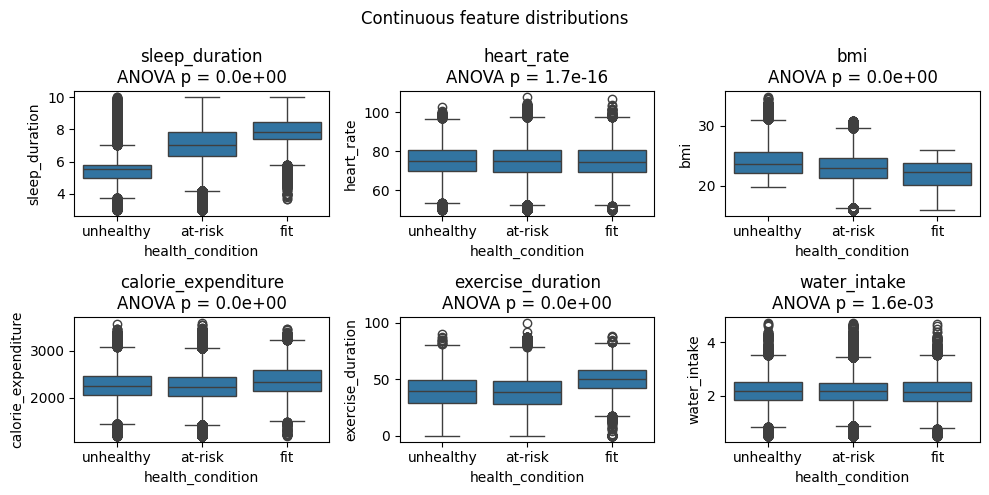

In [18]:
# Empty dict to store ANOVA results for continuous features
results = {
    'Feature': [],
    'ANOVA p-value': []
}

# Setup plot and axes
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
fig.suptitle('Continuous feature distributions')
axs = axs.flatten()

# Loop on features
for i, feature in enumerate([f for f in continuous_features if f != 'step_count']):

    # Run ANOVA test
    feature_values = df[feature].groupby(df[label]).apply(list)
    result = f_oneway(*feature_values.values, nan_policy='omit')

    # Collect ANOVA results
    results['Feature'].append(feature)
    results['ANOVA p-value'].append(result.pvalue)

    # Plot feature distribution
    sns.boxplot(x=label, y=feature, data=df, ax=axs[i])
    axs[i].set_title(f'{feature}\nANOVA p = {result.pvalue:.1e}')
    axs[i].set_xlabel(label)
    axs[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

##### ANOVA table

In [19]:
anova_df = pd.DataFrame(results)
anova_df.sort_values(by='ANOVA p-value', inplace=True)
display(anova_df)

,Feature,ANOVA p-value
0,sleep_duration,0.000000e+00
2,bmi,0.000000e+00
3,calorie_expenditure,0.000000e+00
4,exercise_duration,0.000000e+00
1,heart_rate,1.688808e-16
5,water_intake,1.568885e-03


#### 4.1.3. High cardinality: `step_count`

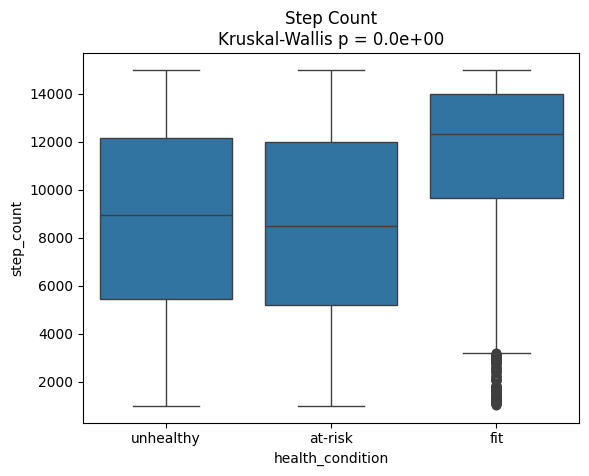

In [20]:
step_counts = df['step_count'].groupby(df[label]).apply(list)
results = kruskal(*step_counts.values, nan_policy='omit')

sns.boxplot(x=label, y='step_count', data=df)
plt.title(f'Step Count\nKruskal-Wallis p = {results.pvalue:.1e}')
plt.show()

### 4.2. Feature-feature

#### 4.2.1. Categorical vs categorical

##### Heatmaps

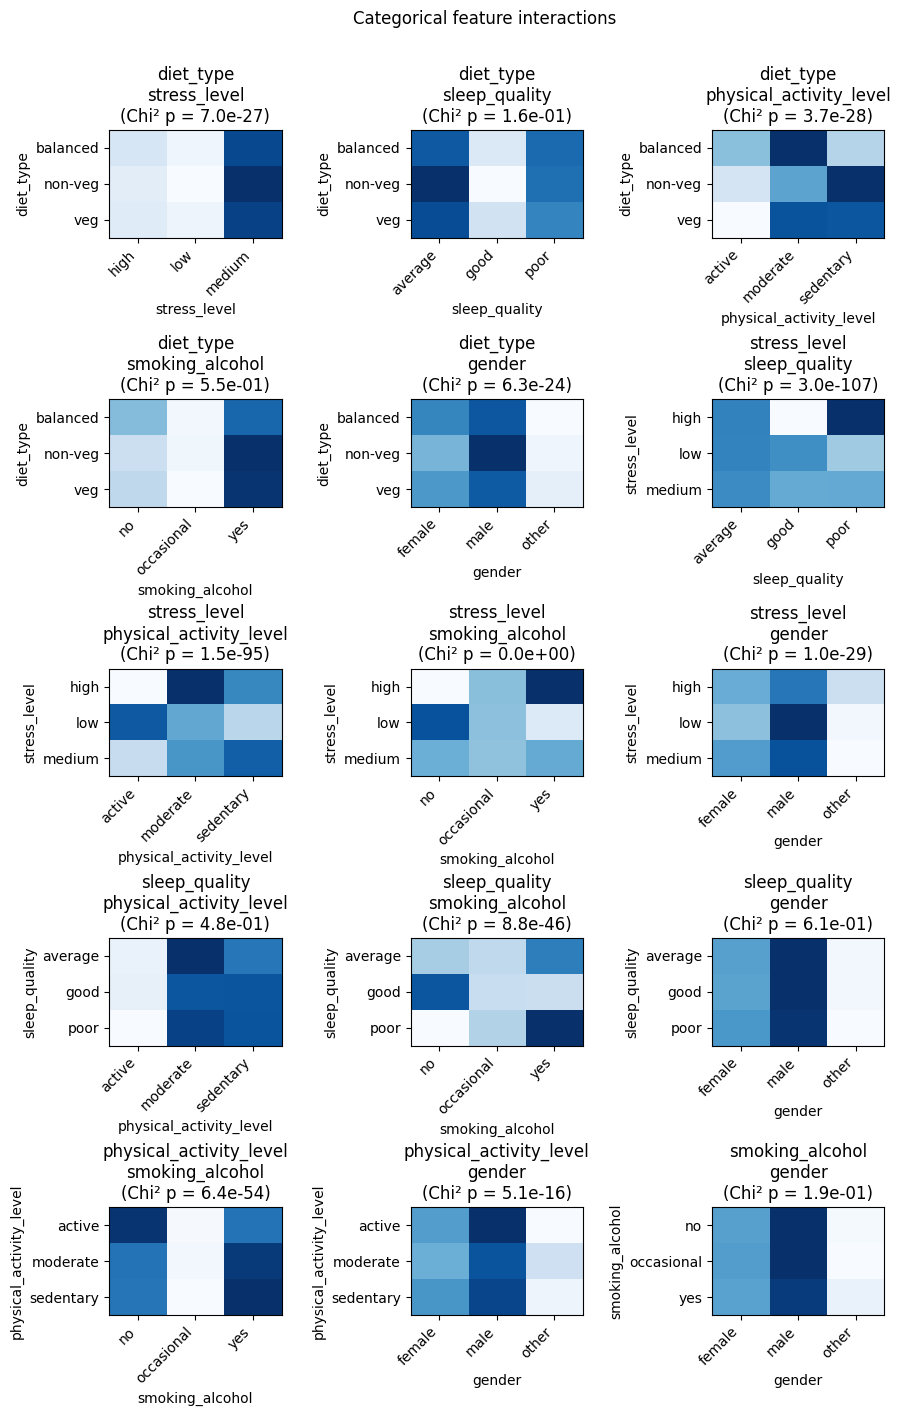

In [21]:
# Empty dictionary to store Chi² test results for categorical feature interactions
results = {
    'Feature X': [],
    'Feature Y': [],
    'Chi² p-value': []
}

# Generate all possible pairs of categorical features for Chi² tests
feature_pairs = list(combinations(categorical_features, 2))

# Set up the figure and axes
fig, axs = plt.subplots(5, 3, figsize=(10, 15))
fig.suptitle('Categorical feature interactions')
axs = axs.flatten()

# Loop on feature pairs
for i, feature_pair in enumerate(feature_pairs):

    # Extract feature names for the current pair
    feature_x, feature_y = feature_pair

    # Create a contingency table for the current pair of features
    contingency_df = pd.crosstab(df[feature_x], df[feature_y])

    # Run the Chi² test for the current pair of features
    result = chi2_contingency(contingency_df)
    p_value = result[1]

    # Collect Chi² test results for later analysis
    results['Feature X'].append(feature_x)
    results['Feature Y'].append(feature_y)
    results['Chi² p-value'].append(p_value)

    # Normalize the contingency table for better visualization
    contingency_df = pd.crosstab(df[feature_x], df[feature_y], normalize='index')

    # Plot the normalized contingency table as a heatmap
    axs[i].imshow(contingency_df, aspect='auto', cmap='Blues')
    axs[i].set_title(f'{feature_x}\n{feature_y}\n(Chi² p = {p_value:.1e})')
    axs[i].set_xlabel(feature_y)
    axs[i].set_ylabel(feature_x)

    # Add feature level labels to x-axis
    axs[i].set_xticks(np.arange(len(contingency_df.columns)))
    axs[i].set_xticklabels(contingency_df.columns, rotation=45, ha='right')

    # Add feature level labels to y-axis
    axs[i].set_yticks(np.arange(len(contingency_df.index)))
    axs[i].set_yticklabels(contingency_df.index)

# Add horizontal space between subplots
plt.subplots_adjust(hspace=1.5)

# Add vertical space between subplots
plt.subplots_adjust(wspace=0.75)

# Adjust layout to decrease space after main title
plt.subplots_adjust(top=0.9)
plt.show()

##### Chi² table

In [22]:
chisquare_results = pd.DataFrame(results)
chisquare_results.sort_values(by='Chi² p-value', inplace=True)
display(chisquare_results)

,Feature X,Feature Y,Chi² p-value
7,stress_level,smoking_alcohol,0.000000e+00
5,stress_level,sleep_quality,3.024848e-107
6,stress_level,physical_activity_level,1.518988e-95
12,physical_activity_level,smoking_alcohol,6.380717e-54
10,sleep_quality,smoking_alcohol,8.822753e-46
8,stress_level,gender,1.012831e-29
2,diet_type,physical_activity_level,3.716048e-28
0,diet_type,stress_level,6.962907e-27
4,diet_type,gender,6.263089e-24
13,physical_activity_level,gender,5.088984e-16


#### 4.2.2. Categorical vs continuous

##### Boxplots

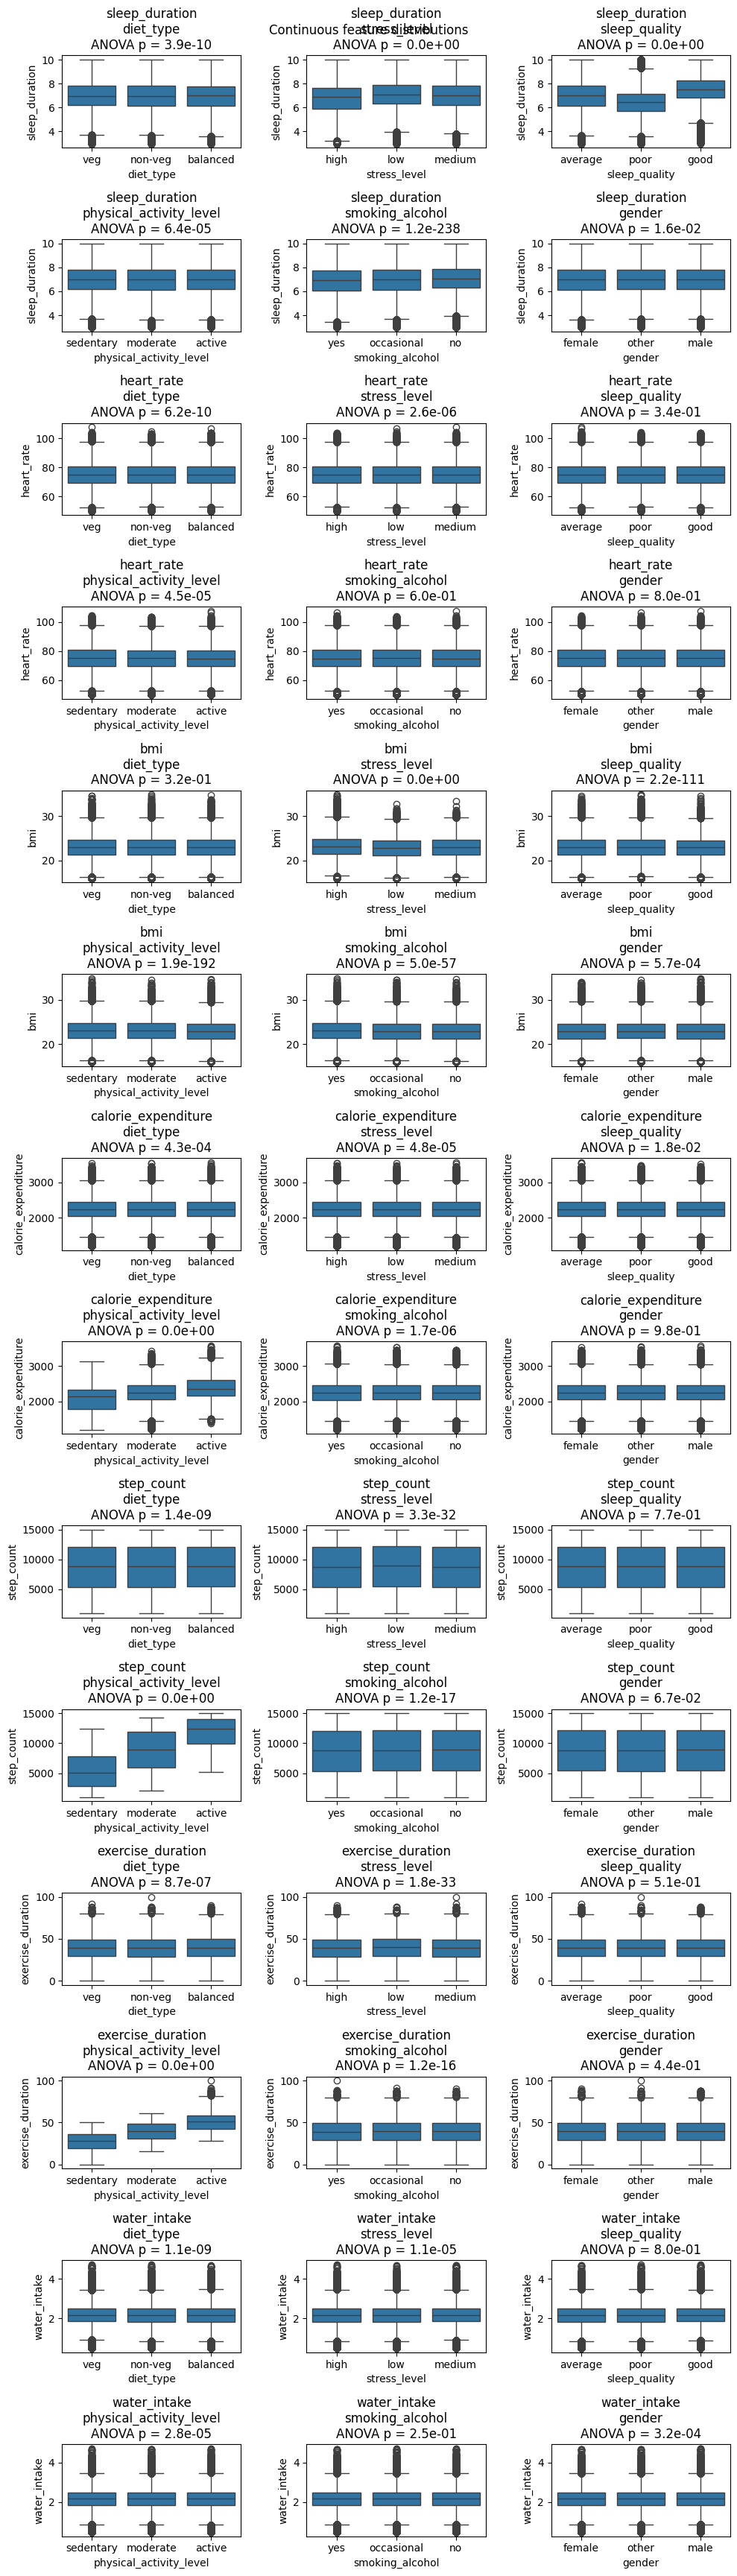

In [23]:
# Empty dict to collect ANOVA results
results = {
    'Continuous Feature': [],
    'Categorical Feature': [],
    'ANOVA p-value': []
}

# Setup the figure and axes for plotting
fig, axs = plt.subplots(14, 3, figsize=(10, 35))
fig.suptitle('Continuous feature distributions')
axs = axs.flatten()

# Initialize subplot index
i = 0

# Loop over continuous and categorical features to perform ANOVA and plot distributions
for continuous_feature in continuous_features:
    for categorical_feature in categorical_features:

        # Perform ANOVA test for the current pair of continuous and categorical features
        feature_values = df[continuous_feature].groupby(df[categorical_feature]).apply(list)
        result = f_oneway(*feature_values.values, nan_policy='omit')

        # Collect ANOVA results for later analysis
        results['Continuous Feature'].append(continuous_feature)
        results['Categorical Feature'].append(categorical_feature)
        results['ANOVA p-value'].append(result.pvalue)

        # Plot the distribution of the continuous feature for each category
        # of the categorical feature
        sns.boxplot(x=categorical_feature, y=continuous_feature, data=df, ax=axs[i])

        axs[i].set_title(
            f'{continuous_feature}\n{categorical_feature}\nANOVA p = {result.pvalue:.1e}'
        )
        axs[i].set_xlabel(categorical_feature)
        axs[i].set_ylabel(continuous_feature)

        # Increment subplot index for the next plot
        i += 1

# Adjust layout to decrease space after main title
plt.subplots_adjust(top=0.9)

plt.tight_layout()
plt.show()

##### ANOVA table

In [24]:
anova_df = pd.DataFrame(results)
anova_df.sort_values(by='ANOVA p-value', inplace=True)
display(anova_df)

,Continuous Feature,Categorical Feature,ANOVA p-value
33,exercise_duration,physical_activity_level,0.000000e+00
1,sleep_duration,stress_level,0.000000e+00
2,sleep_duration,sleep_quality,0.000000e+00
27,step_count,physical_activity_level,0.000000e+00
21,calorie_expenditure,physical_activity_level,0.000000e+00
13,bmi,stress_level,0.000000e+00
4,sleep_duration,smoking_alcohol,1.188295e-238
15,bmi,physical_activity_level,1.891284e-192
14,bmi,sleep_quality,2.211042e-111
16,bmi,smoking_alcohol,5.029840e-57


#### 4.2.3. Continuous vs continuous

##### Heatmaps

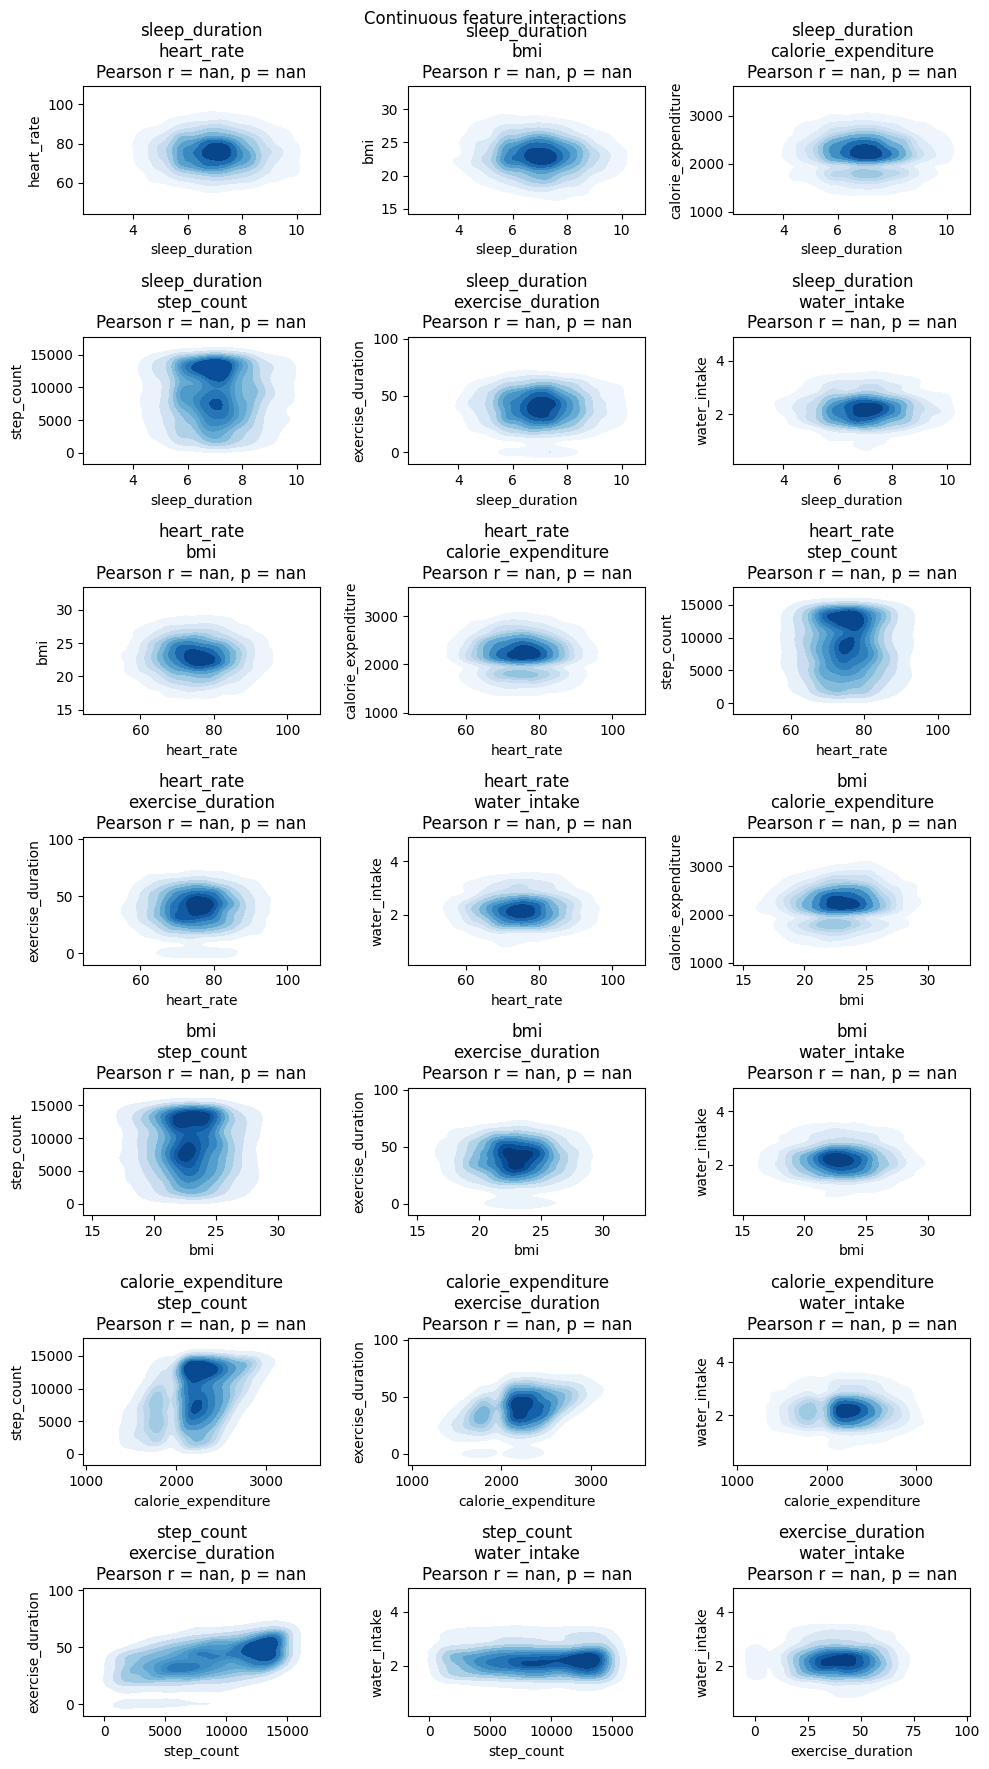

In [25]:
# Empty dict to collect Pearson correlation results
results = {
    'Feature 1': [],
    'Feature 2': [],
    'Pearson r': [],
    'p-value': []
}

# Generate all possible pairs of continuous features for correlation analysis
feature_pairs = list(combinations(continuous_features, 2))

# Setup the figure and axes for plotting
fig, axs = plt.subplots(7, 3, figsize=(10, 18))
fig.suptitle('Continuous feature interactions')
axs = axs.flatten()

# Loop on feature pairs
for i, feature_pair in enumerate(feature_pairs):

    # Get Pearson correlation coefficient
    corr, p_value = pearsonr(df[feature_pair[0]], df[feature_pair[1]])

    # Collect results for later analysis
    results['Feature 1'].append(feature_pair[0])
    results['Feature 2'].append(feature_pair[1])
    results['Pearson r'].append(corr)
    results['p-value'].append(p_value)

    # Get 1% sample
    sample_df = df.sample(frac=0.01, random_state=42)

    # Plot heatmap of the joint distribution
    sns.kdeplot(
        x=sample_df[feature_pair[0]],
        y=sample_df[feature_pair[1]],
        fill=True,
        cmap='Blues',
        ax=axs[i]
    )

    axs[i].set_title(
        f'{feature_pair[0]}\n{feature_pair[1]}\nPearson r = {corr:.2f}, p = {p_value:.1e}'
    )
    axs[i].set_xlabel(feature_pair[0])
    axs[i].set_ylabel(feature_pair[1])

plt.tight_layout()
plt.show()

##### Pearson r table

In [26]:
pearson_df = pd.DataFrame(results)
pearson_df.sort_values(by='p-value', inplace=True)
display(pearson_df)

,Feature 1,Feature 2,Pearson r,p-value
0,sleep_duration,heart_rate,NaN,NaN
1,sleep_duration,bmi,NaN,NaN
2,sleep_duration,calorie_expenditure,NaN,NaN
3,sleep_duration,step_count,NaN,NaN
4,sleep_duration,exercise_duration,NaN,NaN
5,sleep_duration,water_intake,NaN,NaN
6,heart_rate,bmi,NaN,NaN
7,heart_rate,calorie_expenditure,NaN,NaN
8,heart_rate,step_count,NaN,NaN
9,heart_rate,exercise_duration,NaN,NaN
